In [43]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated, Literal
from pydantic import SecretStr, BaseModel, Field

import operator
import os
from dotenv import load_dotenv
load_dotenv()

True

In [44]:
# === Utility Functions ===
def get_secret(key_name: str) -> SecretStr:
    value = os.getenv(key_name)
    if not value:
        raise ValueError(
            f"❌ {key_name} not found. Please set it in your .env file.")
    return SecretStr(value)

In [45]:
model = ChatGroq(
    model="moonshotai/kimi-k2-instruct-0905",
    temperature=0.7,
    api_key=get_secret("GROQ_API_KEY")
)

In [46]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')

In [47]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [48]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [49]:
prompt = 'What is the sentiment of the following review - The software is too good'
structured_model.invoke(prompt).sentiment

'positive'

In [50]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative']
    diagnosis: dict
    response: str

In [51]:
def find_sentiment(state: ReviewState):
    prompt = f'For the following review find out the sentiment\n{state['review']}'
    sentiment = structured_model.invoke(prompt).sentiment
    return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

In [52]:
def positive_response(state: ReviewState):
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    response = model.invoke(prompt).content
    return {'response': response}


def run_diagnosis(state: ReviewState):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)
    return {'diagnosis': response.model_dump()}


def negative_response(state: ReviewState):
    diagnosis = state['diagnosis']
    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content
    return {'response': response}

In [53]:
graph = StateGraph(ReviewState)
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')
graph.add_edge('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

ValueError: Found edge ending at unknown node `<function check_sentiment at 0x00000212C8825BC0>`

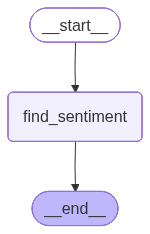

In [ ]:
workflow

In [ ]:
initial_state = {
    'review': 'The product was really good'
}

workflow.invoke(initial_state)

{'review': 'The product was really good', 'sentiment': 'positive'}